# Module 4: Handling Seasonality with SARIMA & SARIMAX 

### Data: ice_cream_interest


## 1. Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_squared_error

## 2. Load Dataset

In [18]:
path= "../data/ice_cream_interest.csv"
df = pd.read_csv(path)

df.head()

,month,interest
0,2004-01,13
1,2004-02,15
2,2004-03,17
3,2004-04,19
4,2004-05,22


## 3. Convert Month to Time Index

In [19]:
df['month'] = pd.to_datetime(df['month'])

df.set_index('month', inplace=True)

df = df.asfreq('MS')  # enforce monthly frequency

df.head()

,interest
month,
2004-01-01,13
2004-02-01,15
2004-03-01,17
2004-04-01,19
2004-05-01,22


## PART 1: EXPLORATORY DATA ANALYSIS (EDA) & DIAGNOSTICS

## 4. Visualize Time Series

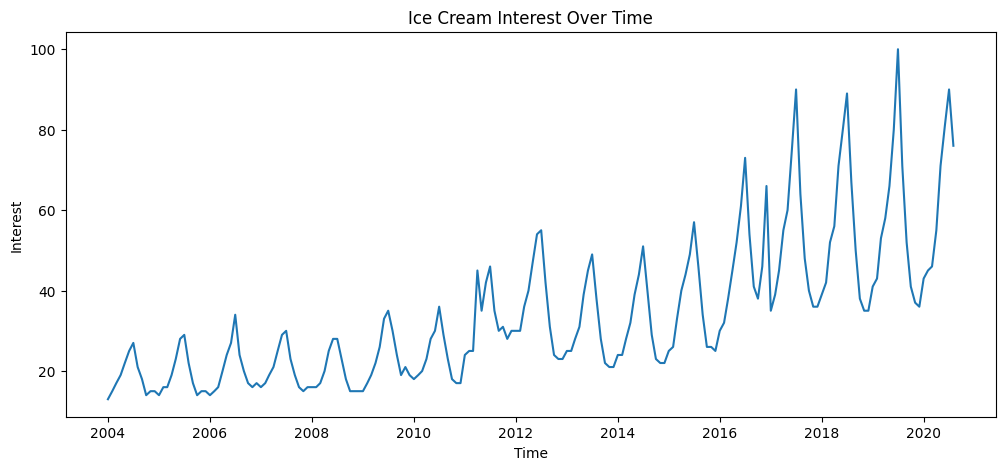

In [20]:
plt.figure(figsize=(12,5))
plt.plot(df['interest'])
plt.title("Ice Cream Interest Over Time")
plt.xlabel("Time")
plt.ylabel("Interest")
plt.show()

## 5. Seasonal Decomposition

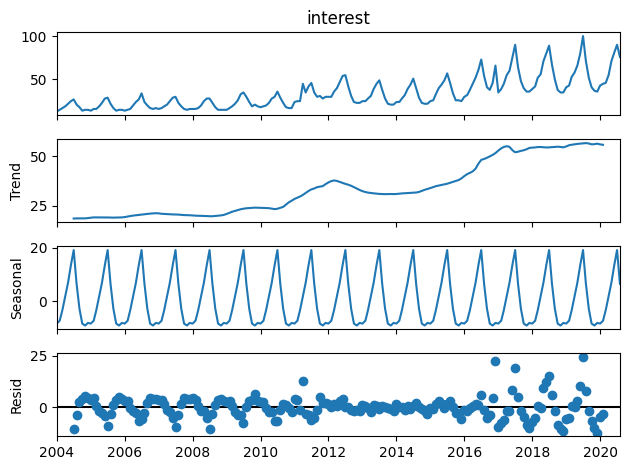

In [21]:
decomposition = seasonal_decompose(df['interest'], model='additive', period=12)

decomposition.plot()
plt.show()

## 6. Stationarity Check (ADF Test)

In [22]:
def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

adf_test(df['interest'])

ADF Statistic: -0.07270677105900515
p-value: 0.9520900977054265


## 7. Seasonal Differencing

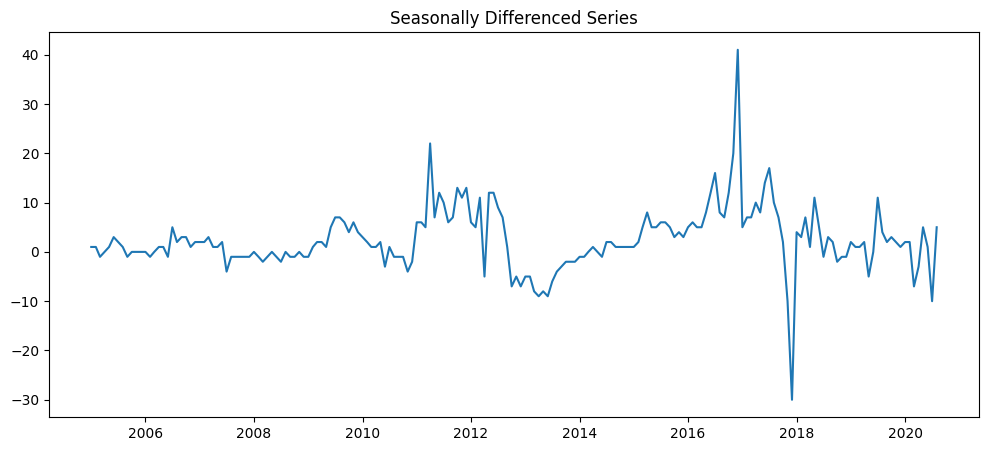

In [23]:
df['seasonal_diff'] = df['interest'] - df['interest'].shift(12)

plt.figure(figsize=(12,5))
plt.plot(df['seasonal_diff'])
plt.title("Seasonally Differenced Series")
plt.show()

## 8. ACF & PACF

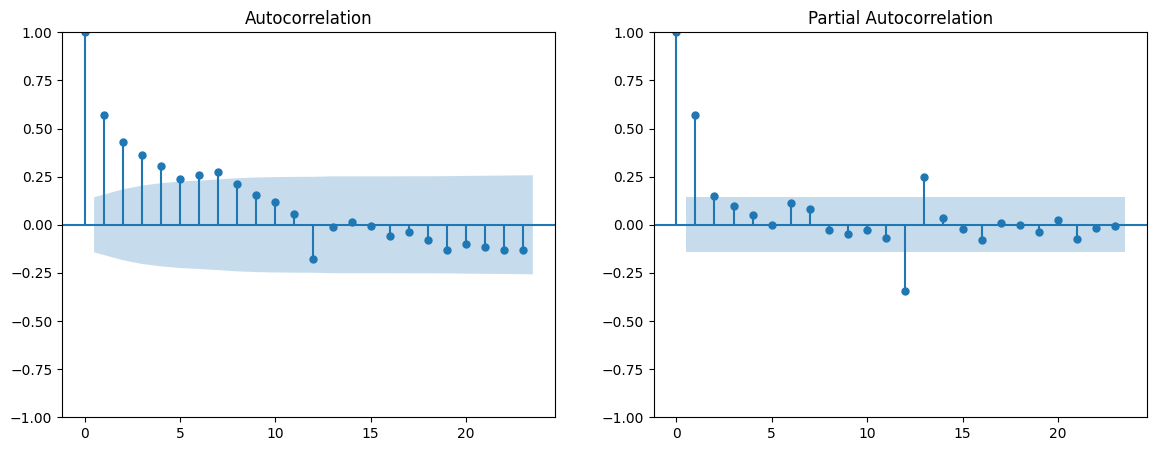

In [24]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

plot_acf(df['seasonal_diff'].dropna(), ax=ax[0])
plot_pacf(df['seasonal_diff'].dropna(), ax=ax[1])

plt.show()

# PART 2: SARIMA MODEL

## 9. Build SARIMA Model
We use a standard starting point:

(p,d,q) = (1,1,1)
(P,D,Q,12) = (1,1,1,12)

In [25]:
model = SARIMAX(
    df['interest'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                           interest   No. Observations:                  200
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -550.392
Date:                            Mon, 01 Jun 2026   AIC                           1110.784
Time:                                    21:43:17   BIC                           1126.939
Sample:                                01-01-2004   HQIC                          1117.330
                                     - 08-01-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4831      0.107      4.514      0.000       0.273       0.693
ma.L1         -0.8487      0.074   

## 10. In-Sample Prediction

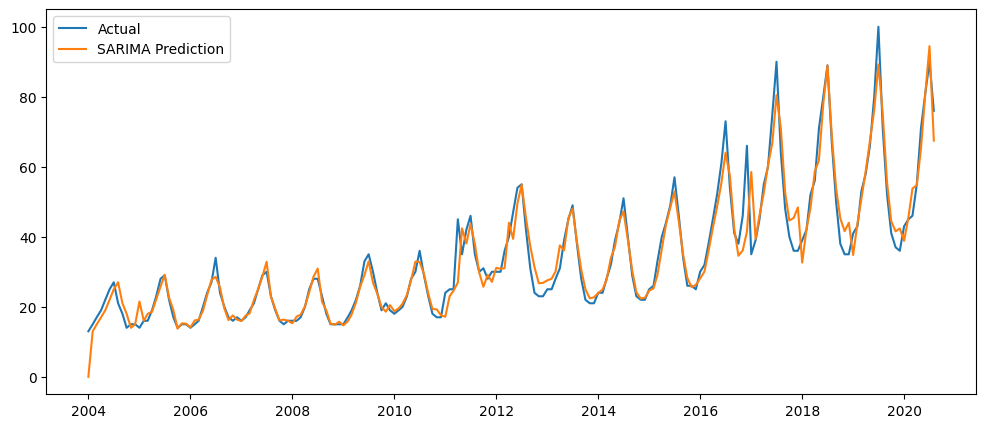

In [26]:
df['sarima_pred'] = results.predict(start=0, end=len(df)-1)

plt.figure(figsize=(12,5))
plt.plot(df['interest'], label='Actual')
plt.plot(df['sarima_pred'], label='SARIMA Prediction')
plt.legend()
plt.show()

## 11. Forecast Future Values

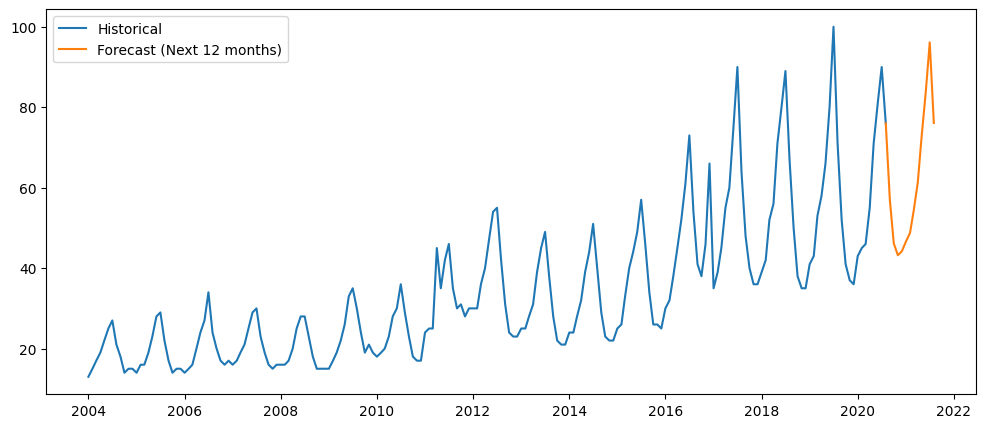

In [27]:
forecast = results.forecast(steps=12)

last_historical_date = df.index[-1]
last_historical_value = df['interest'].iloc[-1]

# Create a small anchor Series for that specific point
forecast_anchor = pd.Series([last_historical_value], index=[last_historical_date])

# 4. Combine the anchor point seamlessly with forecast
final_forecast = pd.concat([forecast_anchor, forecast])

plt.figure(figsize=(12,5))
plt.plot(df['interest'], label='Historical')
plt.plot(final_forecast, label='Forecast (Next 12 months)')
plt.legend()
plt.show()

# PART 3: SARIMAX (with Exogenous Variable)

## 12. Create External Variable

In [28]:
np.random.seed(42)
df['marketing_spend'] = np.random.randint(50, 200, size=len(df))

## 13. Train-Test Split

In [29]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

exog_train = train[['marketing_spend']]
exog_test = test[['marketing_spend']]

## 14. Fit SARIMAX Model

In [30]:
sarimax_model = SARIMAX(
    train['interest'],
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarimax_results = sarimax_model.fit()

print(sarimax_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                           interest   No. Observations:                  160
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -417.885
Date:                            Mon, 01 Jun 2026   AIC                            847.770
Time:                                    21:43:28   BIC                            865.712
Sample:                                01-01-2004   HQIC                           855.060
                                     - 04-01-2017                                         
Covariance Type:                              opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
marketing_spend     0.0019      0.008      0.247      0.805      -0.013       0.017
ar.L1               

## 15. Forecast with External Variable

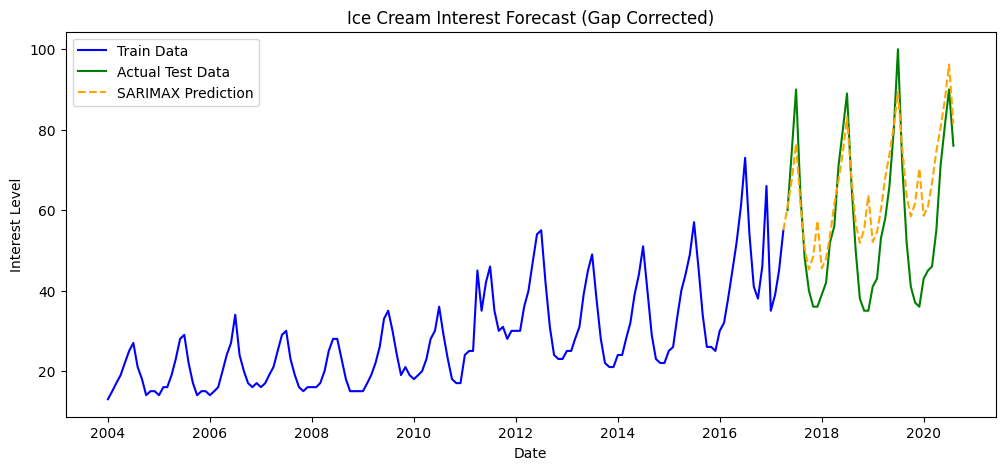

In [31]:
# 1. Generate the predictions (Keep your existing prediction code)
sarimax_pred = sarimax_results.predict(
    start=train_size,
    end=len(df)-1,
    exog=exog_test
)

# 2. Grab the last timestamp and value from the training set to act as a bridge
last_train_date = train.index[-1]
last_train_value = train['interest'].iloc[-1]

# 3. Create a small anchor Series for that specific point
anchor = pd.Series([last_train_value], index=[last_train_date])

# 4. Combine the anchor point seamlessly with your predictions
final_pred = pd.concat([anchor, sarimax_pred])

# 5. Plot the updated, gap-free chart
plt.figure(figsize=(12, 5))
plt.plot(train['interest'], label='Train Data', color='blue')
plt.plot(test['interest'], label='Actual Test Data', color='green')
plt.plot(final_pred, label='SARIMAX Prediction', color='orange', linestyle='--') 
plt.title('Ice Cream Interest Forecast (Gap Corrected)')
plt.xlabel('Date')
plt.ylabel('Interest Level')
plt.legend()
plt.show()

## 16. Evaluate Model

In [32]:
rmse = np.sqrt(mean_squared_error(test['interest'], sarimax_pred))
print("RMSE:", rmse)

RMSE: 13.134967242740094


Summary :
We use models based on 
- SARIMA
Uses only past values of interest
Captures trend + seasonality
Best for stable systems
- SARIMAX
Adds real-world drivers (marketing, weather, etc.)
Much closer to industry forecasting systems
Improves predictive accuracy significantly